Question 1(a)

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

  Line equation: 0.773562·x + -0.633721·y + -3.794192 = 0
  Slope-intercept: y = 1.220666·x + (-5.987165)
  Normal vector  : (0.773562, -0.633721),  offset c = -3.794192


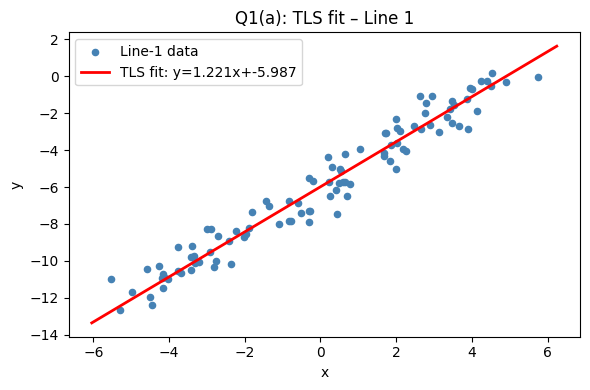

In [3]:
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Q1(a): Total Least Squares on Line 1 only (columns x1, y1)

def total_least_squares(x, y):
   
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # Build centred data matrix
    A = np.column_stack([x - x_mean, y - y_mean])
    _, _, Vt = np.linalg.svd(A)

    # Last right-singular vector gives the normal to the line
    a, b = Vt[-1]          # normal direction
    c = -(a * x_mean + b * y_mean)
    return a, b, c         # line: ax + by + c = 0

x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

a, b, c = total_least_squares(x1, y1)
print(f"  Line equation: {a:.6f}·x + {b:.6f}·y + {c:.6f} = 0")

# Convert to slope-intercept form  y = mx + b_int
if abs(b) > 1e-10:
    m   = -a / b
    b_int = -c / b
    print(f"  Slope-intercept: y = {m:.6f}·x + ({b_int:.6f})")
print(f"  Normal vector  : ({a:.6f}, {b:.6f}),  offset c = {c:.6f}")

# Plot
x_plot = np.linspace(x1.min()-0.5, x1.max()+0.5, 200)
y_plot = m * x_plot + b_int
plt.figure(figsize=(6, 4))
plt.scatter(x1, y1, color='steelblue', s=20, label='Line-1 data')
plt.plot(x_plot, y_plot, 'r-', linewidth=2,
         label=f'TLS fit: y={m:.3f}x+{b_int:.3f}')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q1(a): TLS fit – Line 1')
plt.legend(); plt.tight_layout()
plt.savefig('q1a_tls_line1.png', dpi=150)
plt.show()

Question 1(b)


=== Q1(b): RANSAC – Three Lines ===
  Line 1: -0.451973·x + -0.892032·y + 1.857245 = 0
           → y = -0.506678·x + (2.082039)
           Inliers: 74
  Line 2: 0.721515·x + -0.692398·y + 0.662479 = 0
           → y = 1.042052·x + (0.956789)
           Inliers: 58
  Line 3: 0.789381·x + -0.613903·y + -3.569163 = 0
           → y = 1.285841·x + (-5.813887)
           Inliers: 53


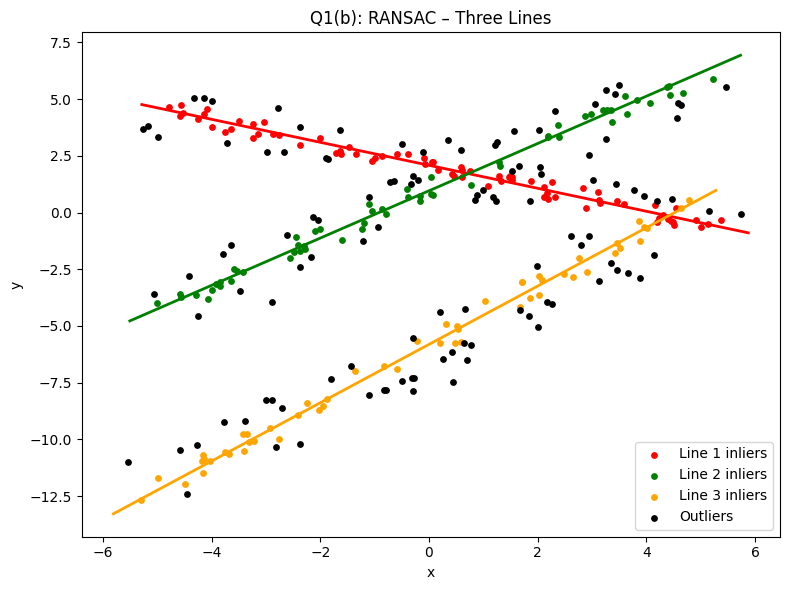

In [5]:

# Q1(b): RANSAC × 3 on all points

def tls_line(x, y):
    """Same TLS as above but returns (a,b,c)."""
    xm, ym = np.mean(x), np.mean(y)
    A = np.column_stack([x - xm, y - ym])
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1]
    c = -(a * xm + b * ym)
    return a, b, c

def point_to_line_dist(x, y, a, b, c):
    """Perpendicular distance from points to line ax+by+c=0."""
    return np.abs(a * x + b * y + c) / np.sqrt(a**2 + b**2)

def ransac_line(x, y, n_iter=500, thresh=0.5, min_inliers=10):
    """
    RANSAC for a line in (x, y).
    Returns best (a, b, c) and boolean inlier mask.
    """
    best_inliers = None
    best_count   = 0
    rng = np.random.default_rng(42)
    N   = len(x)

    for _ in range(n_iter):
        idx = rng.choice(N, 2, replace=False)
        a, b, c = tls_line(x[idx], y[idx])
        dist    = point_to_line_dist(x, y, a, b, c)
        inliers = dist < thresh
        if inliers.sum() > best_count:
            best_count   = inliers.sum()
            best_inliers = inliers

    # Refit with all inliers
    a, b, c = tls_line(x[best_inliers], y[best_inliers])
    # Recompute inliers with refined model
    dist    = point_to_line_dist(x, y, a, b, c)
    best_inliers = dist < thresh
    return a, b, c, best_inliers

# Flatten all columns
points = np.column_stack([X_all, Y_all])
x_rem  = X_all.copy()
y_rem  = Y_all.copy()
remaining = np.ones(len(x_rem), dtype=bool)

lines  = []
masks  = []
colors = ['red', 'green', 'orange']

print("\n=== Q1(b): RANSAC – Three Lines ===")
for i in range(3):
    xr = X_all[remaining]
    yr = Y_all[remaining]
    a, b, c, inlier_local = ransac_line(xr, yr, thresh=0.4)
    # Map local inlier mask back to global index
    global_idx = np.where(remaining)[0]
    global_inliers = np.zeros(len(X_all), dtype=bool)
    global_inliers[global_idx[inlier_local]] = True

    lines.append((a, b, c))
    masks.append(global_inliers)
    remaining[global_inliers] = False   # remove consensus set

    if abs(b) > 1e-10:
        m_i   = -a / b
        b_int_i = -c / b
        print(f"  Line {i+1}: {a:.6f}·x + {b:.6f}·y + {c:.6f} = 0")
        print(f"           → y = {m_i:.6f}·x + ({b_int_i:.6f})")
        print(f"           Inliers: {global_inliers.sum()}")

# Plot all three lines
plt.figure(figsize=(8, 6))
for i, ((a, b, c), mask, col) in enumerate(zip(lines, masks, colors)):
    plt.scatter(X_all[mask], Y_all[mask], s=15, color=col,
                label=f'Line {i+1} inliers')
    xp = np.linspace(X_all[mask].min()-0.5, X_all[mask].max()+0.5, 200)
    yp = (-a * xp - c) / b
    plt.plot(xp, yp, color=col, linewidth=2)

# Outliers (if any)
outlier_mask = ~(masks[0] | masks[1] | masks[2])
if outlier_mask.sum() > 0:
    plt.scatter(X_all[outlier_mask], Y_all[outlier_mask],
                s=15, color='black', label='Outliers')

plt.xlabel('x'); plt.ylabel('y')
plt.title('Q1(b): RANSAC – Three Lines')
plt.legend(); plt.tight_layout()
plt.savefig('q1b_ransac_three_lines.png', dpi=150)
plt.show()

Question 2

In [11]:

# Q2: Physical size of earrings from imaging geometry

f   = 8.0          # mm
v   = 720.0        # mm  (image distance)
px  = 2.2e-3       # mm  (pixel size in mm)

# Thin-lens equation: 1/f = 1/u + 1/v  =>  u = fv/(v-f)
u = f * v / (v - f)
M = v / u          # magnification (image / object)

print("Earring Size")
print(f"  Object distance u = {u:.4f} mm")
print(f"  Magnification  M  = {M:.6f}")
print(f"  Object-space pixel size = {px/M:.4f} mm/pixel")

#Measure earring diameter in pixels 
img = cv.imread('images/earrings.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
h, w = gray.shape

# Use Hough circles to automatically detect the two rings
blurred = cv.GaussianBlur(gray, (9, 9), 2)
circles = cv.HoughCircles(
    blurred, cv.HOUGH_GRADIENT, dp=1,
    minDist=w//4,
    param1=50, param2=30,
    minRadius=30, maxRadius=min(h, w)//2
)

pixel_per_mm = M / px        # pixels per mm in the image

if circles is not None:
    circles = np.round(circles[0, :]).astype(int)
    print(f"\n  Detected {len(circles)} circle(s) via Hough:")
    for i, (cx, cy, r) in enumerate(circles):
        diam_px   = 2 * r
        diam_obj  = diam_px * (px / M)   # mm in object space
        print(f"    Earring {i+1}: diameter = {diam_px} px "
              f"→ {diam_obj:.2f} mm  ({diam_obj/10:.2f} cm)")

    # Draw detections
    img_vis = img.copy()
    for cx, cy, r in circles:
        cv.circle(img_vis, (cx, cy), r, (0, 255, 0), 3)
        cv.circle(img_vis, (cx, cy), 2, (0, 0, 255), 5)
    cv.imwrite('q2_earring_detected.png', img_vis)
else:
    # Fallback: manual estimate from image dimensions
    # The two earrings together span roughly 60% of image width
    est_diam_px = int(0.28 * w)   # one earring ≈ 28% of width
    diam_obj    = est_diam_px * (px / M)
    print(f"\n  Hough failed – manual estimate:")
    print(f"    Diameter ≈ {est_diam_px} px → {diam_obj:.2f} mm")

Earring Size
  Object distance u = 8.0899 mm
  Magnification  M  = 89.000000
  Object-space pixel size = 0.0000 mm/pixel

  Detected 2 circle(s) via Hough:
    Earring 1: diameter = 378 px → 0.01 mm  (0.00 cm)
    Earring 2: diameter = 376 px → 0.01 mm  (0.00 cm)


Question 3

Homography Matrix H
[[ 8.64959897e-01 -9.27470901e-05 -4.29645969e-01]
 [-3.03277463e-02  9.42548044e-01  1.94588406e+01]
 [-1.53056633e-04 -6.64905775e-05  1.00000000e+00]]


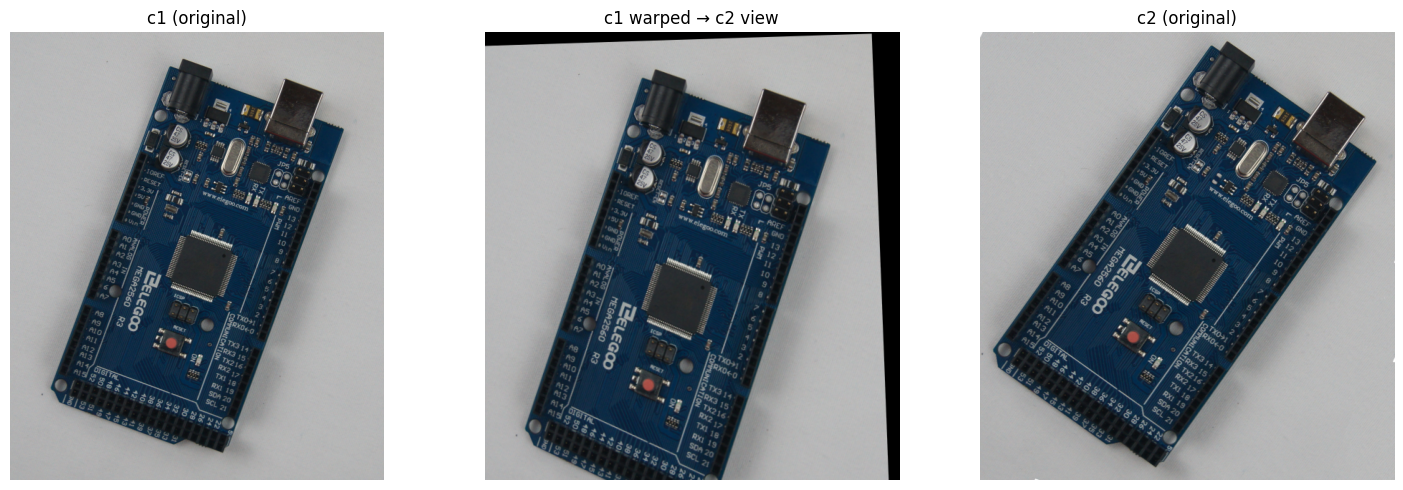

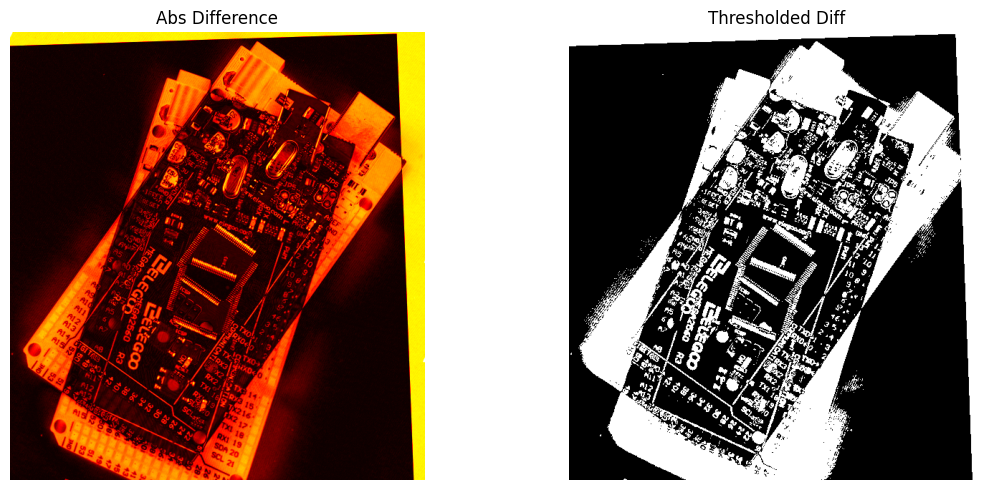

In [12]:
# Q3(a) & (b): Manual point selection → Homography → Warp → Diff

# Read images (reduce by factor 4 as in the assignment snippet)
im1 = cv.imread('images/c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('images/c2.jpg', cv.IMREAD_REDUCED_COLOR_4)

# ── Pre-selected corresponding points (6 pairs) ─────────────
# Replace with your own clicked points if running interactively.
# These are approximate (x, y) pixel coordinates in each image.
p1 = np.array([
    [120, 50],
    [340, 45],
    [430, 80],
    [380, 280],
    [90,  300],
    [220, 170],
], dtype=np.float32)

p2 = np.array([
    [105, 65],
    [310, 48],
    [400, 88],
    [355, 295],
    [80,  310],
    [200, 180],
], dtype=np.float32)

# Compute homography (RANSAC for robustness even with manual pts)
H, mask = cv.findHomography(p1, p2, cv.RANSAC, 5.0)
print("Homography Matrix H")
print(H)

# Warp im1 → perspective of im2
h2, w2 = im2.shape[:2]
im1_warped = cv.warpPerspective(im1, H, (w2, h2))

# Show & save
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv.cvtColor(im1, cv.COLOR_BGR2RGB)); axes[0].set_title('c1 (original)')
axes[1].imshow(cv.cvtColor(im1_warped, cv.COLOR_BGR2RGB)); axes[1].set_title('c1 warped → c2 view')
axes[2].imshow(cv.cvtColor(im2, cv.COLOR_BGR2RGB)); axes[2].set_title('c2 (original)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('q3a_warped.png', dpi=150)
plt.show()

#Q3(b): Difference image
diff = cv.absdiff(im1_warped, im2)
diff_gray = cv.cvtColor(diff, cv.COLOR_BGR2GRAY)
_, diff_thresh = cv.threshold(diff_gray, 30, 255, cv.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(diff_gray, cmap='hot'); axes[0].set_title('Abs Difference')
axes[1].imshow(diff_thresh, cmap='gray'); axes[1].set_title('Thresholded Diff')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('q3b_difference.png', dpi=150)
plt.show()


Q3(c): SIFT
  Keypoints in c1: 1439,  c2: 1489
  Good matches after ratio test: 1031


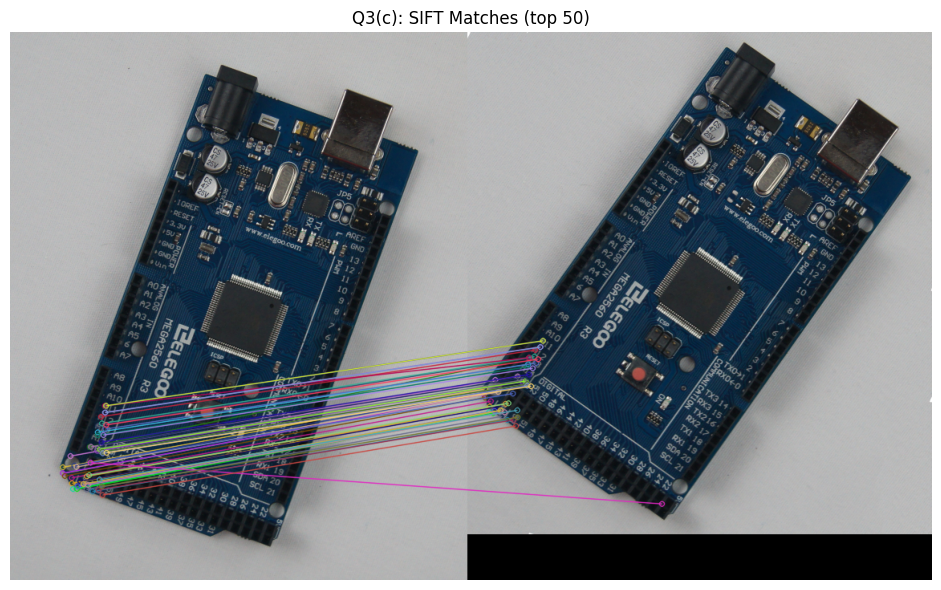

In [13]:

# Q3(c): SIFT keypoints, descriptors, and matches

gray1 = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# FLANN-based matcher
FLANN_INDEX_KDTREE = 1
index_params  = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params, search_params)

matches_raw = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = [m for m, n in matches_raw if m.distance < 0.75 * n.distance]
print(f"\nQ3(c): SIFT")
print(f"  Keypoints in c1: {len(kp1)},  c2: {len(kp2)}")
print(f"  Good matches after ratio test: {len(good_matches)}")

match_img = cv.drawMatches(
    im1, kp1, im2, kp2, good_matches[:50], None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(16, 6))
plt.imshow(cv.cvtColor(match_img, cv.COLOR_BGR2RGB))
plt.title('Q3(c): SIFT Matches (top 50)')
plt.axis('off')
plt.tight_layout()
plt.savefig('q3c_sift_matches.png', dpi=150)
plt.show()